# Trabajo Semanal N°1 : 'Sintesis y operaciones de señales'
### Alumno: Magdalena Guida

### APS - 1er cuatrimestre 2026

Este trabajo tiene como objetivo explorar la sintesis y el analisis de señales temporales utilizando las herramientas que ofrecen las librerias de Python, como NumPy, SciPy y Matplotlib. A traves de estas ellas, se diseñaron y manipularon distintas señales, como sinusoidales, cuadradas y pulsos. Para cada señal generada se variaron caracteristicas como la frecuencia, fase y  amplitud. Donde la frecuencia, $f$ representa la cantidad de veces que se repite el patron de la señal periodica en $1$ segundo, se mide en $Hz$. La fase determina cuanto se adelanta o atrasa la señal respecto a esa misma señal pura y la amplitud, $A$, refelja la distancia entre el eje de simetria de la señal, que normalmente es cero, y el punto mas alto que alcanza, sobre el eje y. 

Tambien, se estudio la potencia y energia de las señales, que ambas son maneras de medir la intensidad. El detalle que las diferencia recae en que la energia se mide sobre su total, para señales periodicas esto tenderia al infinito, por lo que se aplica la potencia de la señal que mide la intensidad contenida en una unidad de tiempo, mas especificamente sobre el periodo. 

La potencia, utilizada para las señales senoidales y la cuadrada, se define como: $ P= \frac{1}{T} \int_{0}^{T} |x(t)|^{2} \,dt$. En el caso particular de las senoidales se podria realizar un despeje de la formula y se obtener la ecuacion $P =\frac{A^{2}}{2}$ y para las señales cuadradas $P = A^{2}$. En la aplicacion, se utilizo la funcion *np.mean* con la precaucion de que las señales cumplan *n*-cantidad de periodos completos, para que el calculo sea correcto. Para el caso de la señal pulso, se calculo su energia, por ser una señal no periodica, se utiliza la funcion *np.mean* del cuadrado de la señal, que calcula el promedio de todos sus valores. 

La señal nuemero 2, pide ser $3dB$ mayor que la senoidal 1. Se logro usando la definicion: $dB = 20* log_{10}(\frac{A_{2}}{A_{1}})$, despejando la amplitud de la segunda senoidal, se obtiene: $A_{2} = A_{1}*10^\frac{3}{20}$
La señal senoidal numero 3, se construye a partir de la  modulacion, que es una operacionque se realiza entre señales, en donde se hace la multiplicacion punto a punto y se espera una señal resultante con atributos de las señales originales. 
La señal senoida numero 4, es la señal numero 3, pero al 75% de su amplitud. Para logralo, se calcula el punto minimo y maximo de $y3$, y se utiliza la funcion $np.clip$ definiendole los parametros: $a_{min} = min(y3)*0.75$ y $a_{max} = max(y3)*0.75$. Esta funcion determina para cada punto de $y4$ si se encuentra dentro del rango definido, cuando no cumplen con la condicion, le reemplaza su valor por el parametro mas cercano. 

Se diseñaron y graficaron señales: 
- Señal senoidal: Frecuencia= $2kHz$, amplitud= $A=1$ 
- Señal senoidal: Frecuencia= $2kHz$, desfasaje= $\frac{\pi}{2}$, amplitud= $3 dB$ mayor que la anterior: $A = 1*10^\frac{3}{20} = 1.4125$
- Señal senoidal: Misma señal, pero modulada en amplitud por una senoidal de frecuencia= $1kHz$
- Señal senoidal: Señal anterior con efecto de saturacion al $75$% de su amplitud
- Señal cuadrada: Frecuencia= $4kHz$, amplitud= $A = 1$
- Señal pulso de 10ms de duracion 

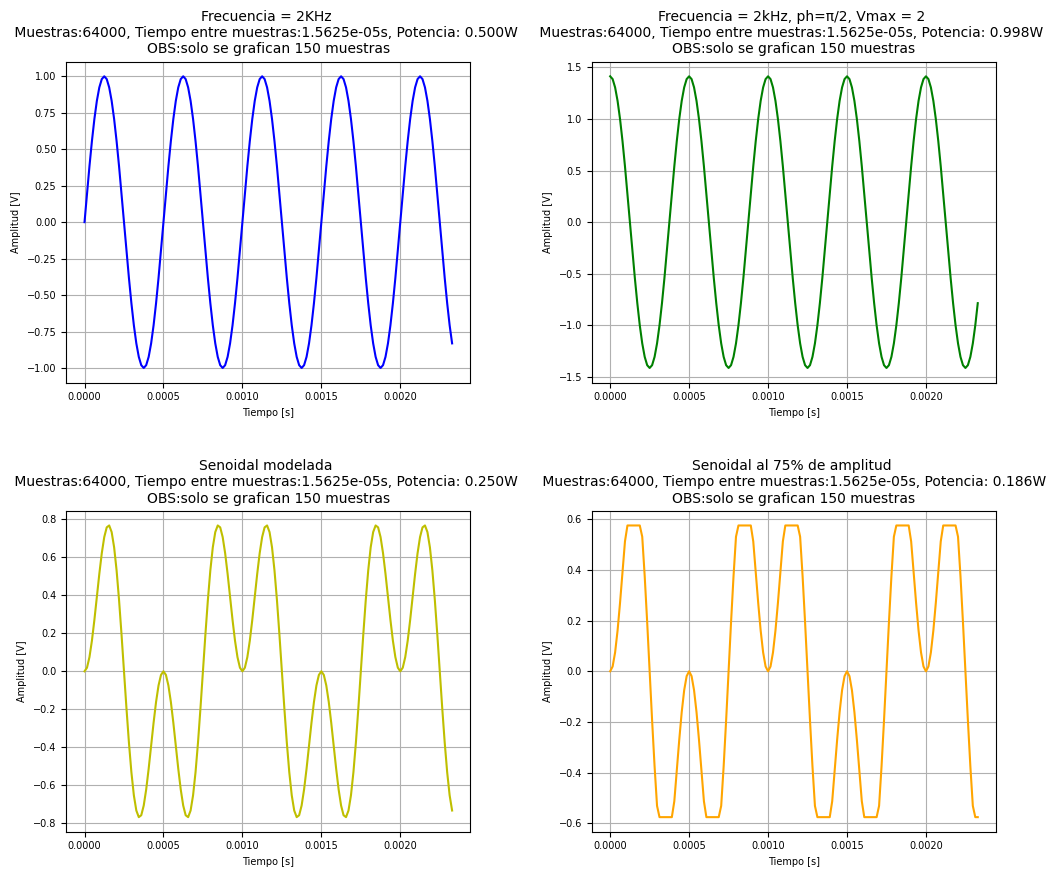

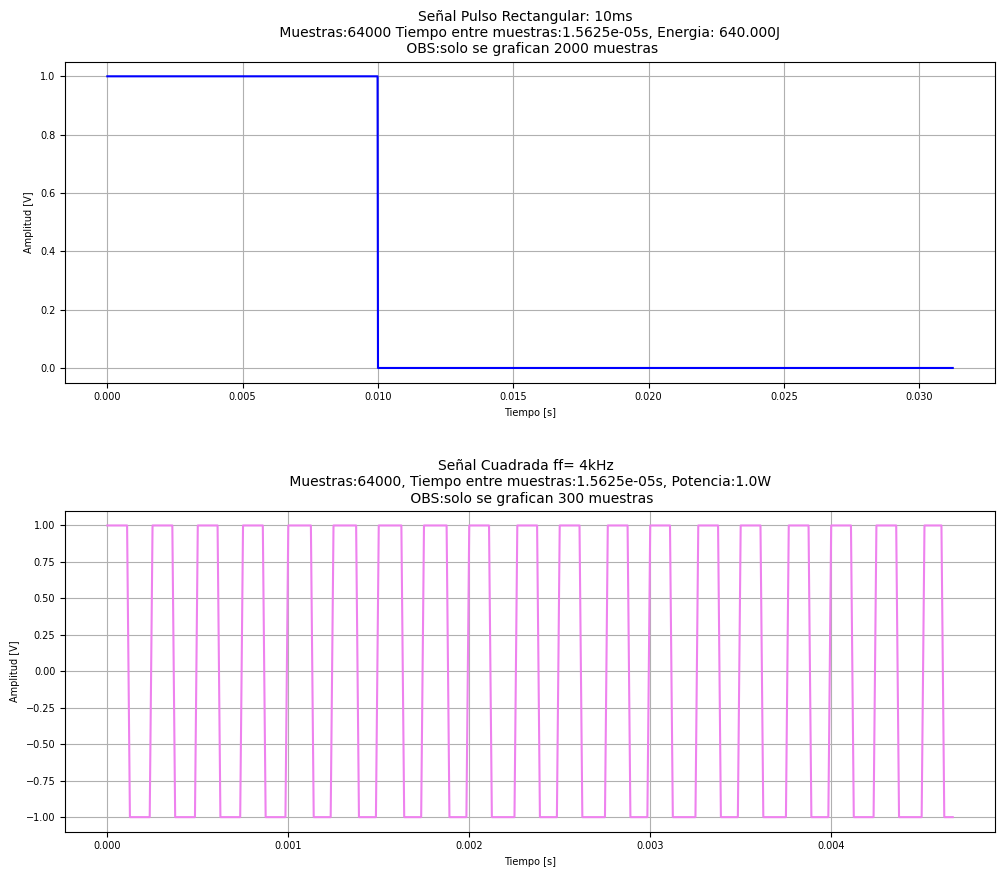

In [21]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from scipy.signal import lfilter

N = 64000   # Número de muestras
fs = N   # Frecuencia de muestreo
T = 1 / fs  # Tiempo de muestreo = Ts 
df = fs / N  # Resolución espectral  
dc = 0       #Desplazamiento vertical [V]  
ph = 0       #FASE = Desplazamiento horizontal [rad]

# Definicion funciónes seno
def func_sen(Vmax=1, dc=dc, ff=1, ph=ph, nn=N, fs=fs):    
    N= np.arange(nn)
    tt = N/fs    
    xx = Vmax * np.sin(2 * np.pi * ff * tt + ph).reshape(nn,1) + dc    
    return tt, xx

# Definicion funcion cuadrada
def func_square(Vmax=1, dc=dc, ph=ph, nn=N, fs=fs, ff=1, duty= 1/2):   
    N= np.arange(nn)
    tta = N/fs
    xxa = Vmax * signal.square(2 * np.pi * tta * ff + ph, duty=duty ).reshape(nn, 1) + dc  
    return tta, xxa

def func_escalon(Vmax=1, ff=1, fs=fs, nn= N, duracion = 1, comienzo = 0 ):
    N = np.arange(nn)
    t = N/fs
    u = np.where(t < duracion, Vmax, 0)
    return t, u
    
A1 = 1
A2 = A1 * 10**(3/20)    
    
t1, y1 = func_sen(Vmax = 1, ff = 2000)                     ## SENOIDAL BASE 
t2, y2 = func_sen(ff = 2000, Vmax = A2, ph = np.pi/2)     ## AMPLIADA Y DESFAZADA
ta, ya = func_sen(ff = 1000)                              ## MITAD DE FREC
y3 = y1 * ya                                              ## MODELADA t3 = t1
#y4 = np.max(y3) * 0.75
max= np.max(y3)
min = np.min(y3)
y4 = np.clip(y3, a_min=min*0.75, a_max= max*0.75)        ## 75% DE AMP
t5, u = func_escalon(duracion = 0.01)
t6, y6 = func_square(ff=4000)

## CALCULO DE ENERGIA / POTENCIA 
P1 = np.mean(y1**2)
P2 = np.mean(y2**2)
P3 = np.mean(y3**2)
P4 = np.mean(y4**2)
P5 = np.sum(np.abs(u)**2) 
E6 = np.sum(np.abs(y6)**2) * 1/N

#%% EJE 1 GRAFS:   
# # GRAFICO 1:
     
senales = [
    ("Frecuencia = 2KHz", f"Muestras:{N}, Tiempo entre muestras:{T}s, Potencia:{P1: .3f}W ","OBS:solo se grafican 150 muestras", t1[:150], y1[:150], 'b'),
    ("Frecuencia = 2kHz, ph=π/2, Vmax = 2", f"Muestras:{N}, Tiempo entre muestras:{T}s, Potencia:{P2: .3f}W ", "OBS:solo se grafican 150 muestras",t2[:150], y2[:150], 'g'),
    ("Senoidal modelada",  f"Muestras:{N}, Tiempo entre muestras:{T}s, Potencia:{P3: .3f}W ","OBS:solo se grafican 150 muestras", t1[:150], y3[:150], 'y'),
    ("Senoidal al 75% de amplitud", f"Muestras:{N}, Tiempo entre muestras:{T}s, Potencia:{P4: .3f}W","OBS:solo se grafican 150 muestras", t1[:150], y4[:150], 'orange'),
]                                    
fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharex=False)
axs = axs.flatten()
fig.subplots_adjust(hspace=0.4, wspace=0.3)

for i, (titulo, subtitulo, obs, tiempo, señal, color) in enumerate(senales):
    axs[i].plot(tiempo, señal, color=color)
    axs[i].set_title(f"{titulo} \n {subtitulo} \n{obs}", fontsize= 10)
    axs[i].set( xlabel="Tiempo [s]", ylabel="Amplitud [V]")
    axs[i].tick_params(axis='both', labelsize=7)  # achica nros de los ejes
    axs[i].xaxis.label.set_size(7)                # achica nombre eje X
    axs[i].yaxis.label.set_size(7)                # achica nombre eje Y
    axs[i].grid(True) 

# GRAFICO 2:
senales2 = [
    ("Señal Pulso Rectangular: 10ms ",f"Muestras:{N} Tiempo entre muestras:{T}s, Energia:{P5: .3f}J"," OBS:solo se grafican 2000 muestras", t5[:2000], u[:2000], 'blue'),
    ("Señal Cuadrada ff= 4kHz ",f"Muestras:{N}, Tiempo entre muestras:{T}s, Potencia:{E6}W", " OBS:solo se grafican 300 muestras", t6[:300], y6[:300], 'violet')
    ]
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=False)
axs = axs.flatten()
fig.subplots_adjust(hspace=0.4, wspace=0.3)

for i, (titulo, subtitulo, obs, tiempo, señal, color) in enumerate(senales2):
    axs[i].plot(tiempo, señal, color=color)
    axs[i].set_title(f"{titulo} \n {subtitulo} \n{obs}", fontsize= 10)
    axs[i].set( xlabel="Tiempo [s]", ylabel="Amplitud [V]")
    axs[i].tick_params(axis='both', labelsize=7)  # achica nros de los ejes
    axs[i].xaxis.label.set_size(7)                # achica nombre eje X
    axs[i].yaxis.label.set_size(7)                # achica nombre eje Y
    axs[i].grid(True) 
    
plt.show()

La segunta parte del trabajo consiste en calcular la salida del sistema LTI: $y[n] = x[n]*h[n]$, cuya respuesta alimpulso es: $h[n] = \delta[n] - \delta[n-4]$, para distintas entradas $x[n]$. Basicamente, $y$ devuelve el valor original de $x$, restandole su valor retrasado en 4 muestras. 

Se utlizaron $x[n]$: 

1) $x1[n] = cos( w0 * n * Ts )$,respetando que la solucion se exprese de la forma: $A*cos( w0 * n * Ts + \gamma)$
2) $x2[n] = (1/2)^{2} * u[n]$
3) $x3[n]= u[n+1] -u[u-2]$

Siendo $u[n]$ la funcion escalon.

Los calculos se realizaon a mano y se muestran a continuacion: 

In [14]:
from IPython.display import IFrame

pdf_path = "../TS 1/ej2-ts1.pdf"
IFrame(pdf_path, width=800, height=600)

La corroboracion de las cuentas se hizo a travez de un codigo que imprime primero los graficos de las señales, despues la funcion $h$ y por ultimo la convolucion entre ambos. El **codigo** fue **diseñado por AI**. 
En primer lugar definio como variables del mismo largo a $n$, que se empleara en las entradas, y $m$, que se usa para la funcion $h$. Luego, se definen: la funcion escalon, una delta discreta y h. $u$, fue declarada con la herramienta lamba, que abre una 'funcion anonima' en la que se usa la $Heaviside$. Se le introducen dos parametros y define el primero como la posicion: $x$ y el segundo, un valor establecido: $1$, y devuelve $0$ si $x<0$ o $1$ si $x>0$. La funcion $delta$ se establece como un array de ceros excepto un $1$ en $k=0$, y se utiliza para formar $h$ como la resta entre deltas *shifted*.
Declara las señales de entrada y calcula las salidas con $np.convolve$. Por ultimo, define el eje temporal de las salidas teniendo en cuenta que para la convolucion $y[ny] = x[n]*h[m]$ se calcula como: $ny_{min} = n_{min} + m_{min}; ny_{max} = n_{max} + m_{max}$. En el codigo se le agrega un $+1$ al $ny_{max}$ por el $np.arange$.  
Por ultimo, grafica. 

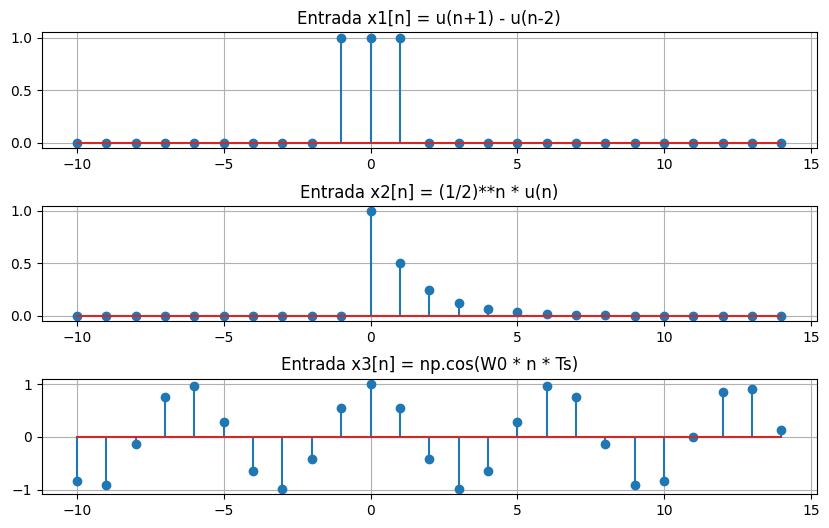

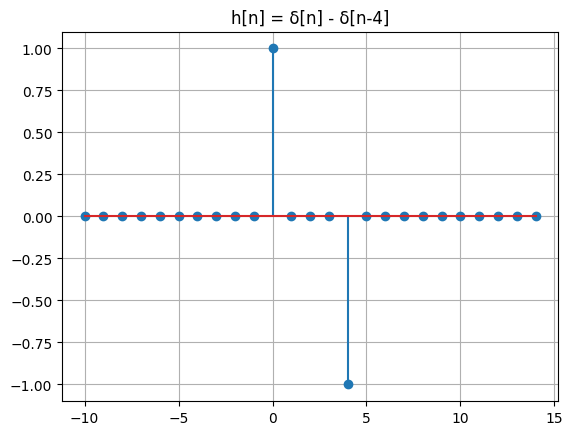

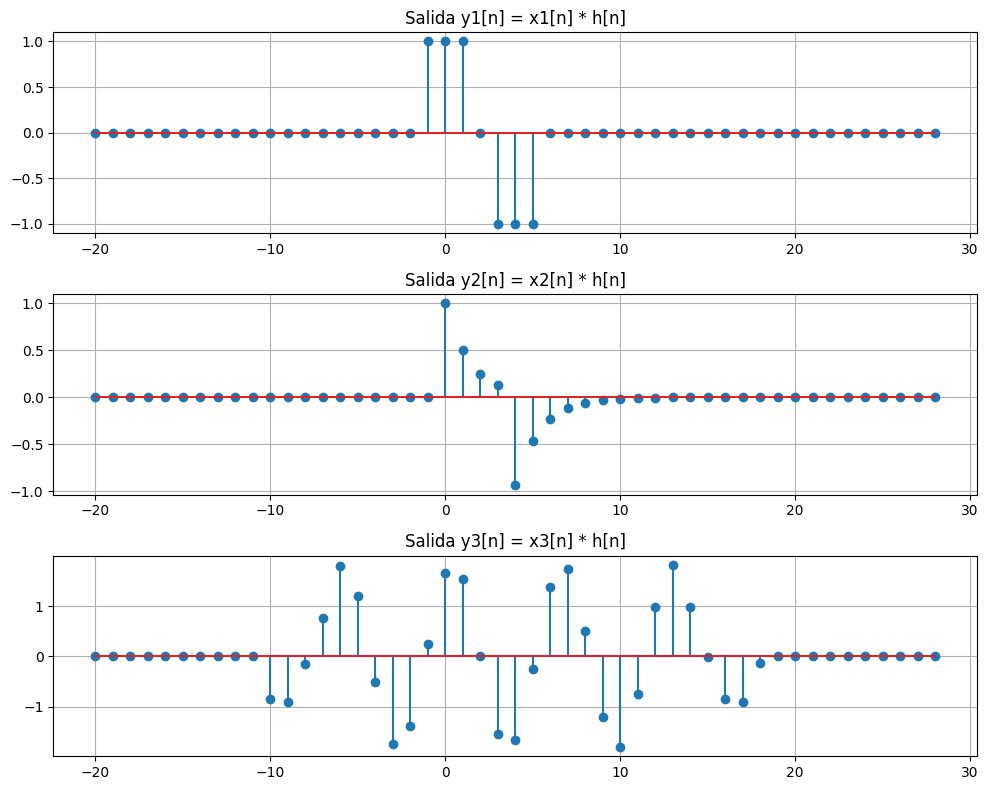

In [19]:
import numpy as np
import matplotlib.pyplot as plt

#variable para señales de entrada
n = np.arange(-10, 15)
#variable para h
m = np.arange(-10, 15)

# Función escalón
u = lambda x: np.heaviside(x, 1)

# Delta discreta
def delta(k):
    return np.array([1 if i == 0 else 0 for i in k])
    
# Respuesta impulsiva: h[n] = δ[n] - δ[n-4]
h = delta(m) - delta(m-4)    

W0 = 1
Ts = 1

# Señales Entrada
x1 = u(n+1) - u(n-2)
x2 = (1/2)**n * u(n)
x3 = np.cos(W0 * n * Ts)

# Convolución: y[n] = x[n] * h[n]
y1 = np.convolve(x1, h)
y2 = np.convolve(x2, h)
y3 = np.convolve(x3, h)

# Nuevo eje temporal para la salida
ny = np.arange(n[0] + m[0], n[-1] + m[-1] + 1)

#%%
# GRAFICOS

## graf señales
plt.figure(figsize=(10,6))
plt.subplots_adjust(hspace= 0.5)

plt.subplot(3,1,1)
plt.stem(n, x1)
plt.title("Entrada x1[n] = u(n+1) - u(n-2)")
plt.grid(True)

plt.subplot(3,1,2)
plt.stem(n, x2)
plt.title("Entrada x2[n] = (1/2)**n * u(n)")
plt.grid(True)

plt.subplot(3,1,3)
plt.stem(n, x3)
plt.title("Entrada x3[n] = np.cos(W0 * n * Ts)")
plt.grid(True)

## graf rta al impulso
plt.figure()
plt.stem(m, h)
plt.title("h[n] = δ[n] - δ[n-4]")
plt.grid(True)

##graf salida conv
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.stem(ny, y1)
plt.title("Salida y1[n] = x1[n] * h[n]")
plt.grid(True)

plt.subplot(3,1,2)
plt.stem(ny, y2)
plt.title("Salida y2[n] = x2[n] * h[n]")
plt.grid(True)

plt.subplot(3,1,3)
plt.stem(ny, y3)
plt.title("Salida y3[n] = x3[n] * h[n]")
plt.grid(True)

plt.tight_layout()
plt.show()

Los calculos y graficos hechos a mano coinciden con los resultados que proyecta el codigo, por lo que se corrobora su vericidad. 

A lo largo del trabajo se logro diseñar, manipular y analizar distintos tipos de señales. Se exploraron distintas propiedades y se las tradujo a codigo para poder mostraralas. Se trabajo con conceptos que caracterizan a las señales, indicandolos para cada una de ellas en los graficos. En la segunda parte, se rabajo con sistemas LTI, tanto con calculos a mano como con herramientas de python y AI para mostrar distintos metodos de solucion para un mismo problema. 